Loaded Smarr FEMALE data: 14 females, 11520 minutes total
Using first 8 days (11520 minutes) per female (includes day 9)
Loaded Smarr MALE data: 6 males, 11520 minutes total
Using first 8 days (11520 minutes) per male (includes day 9)


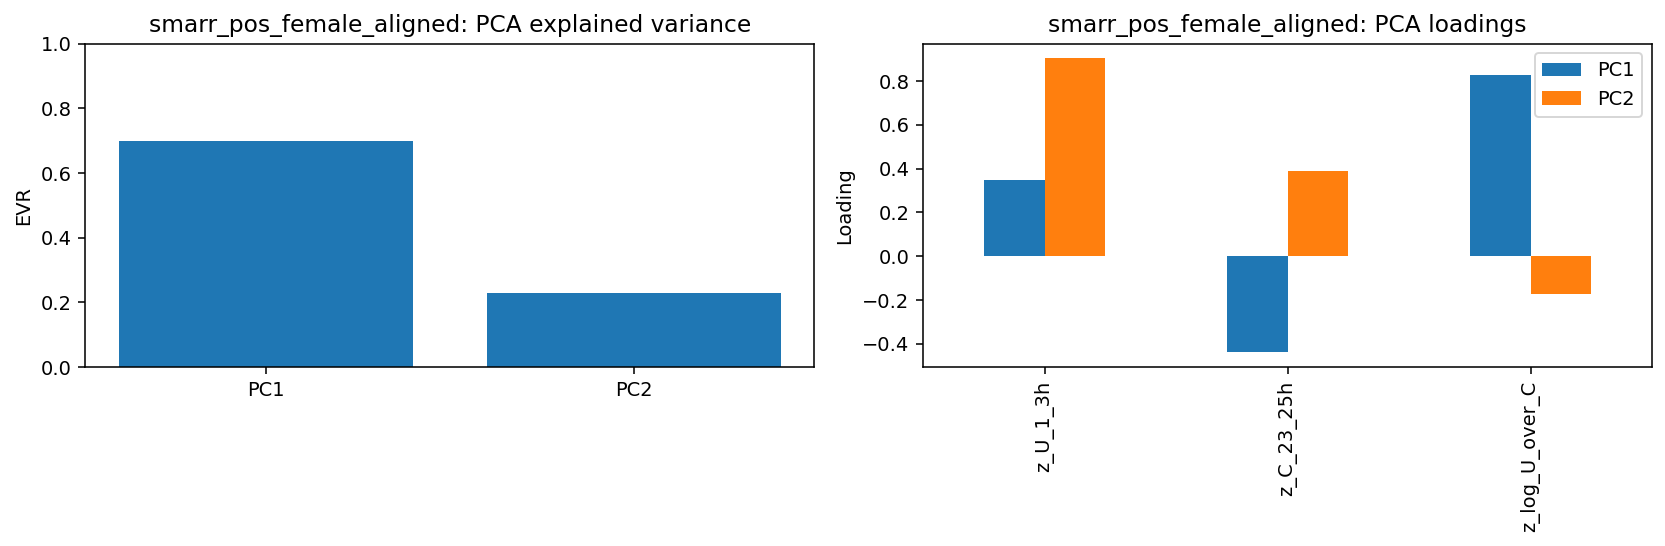

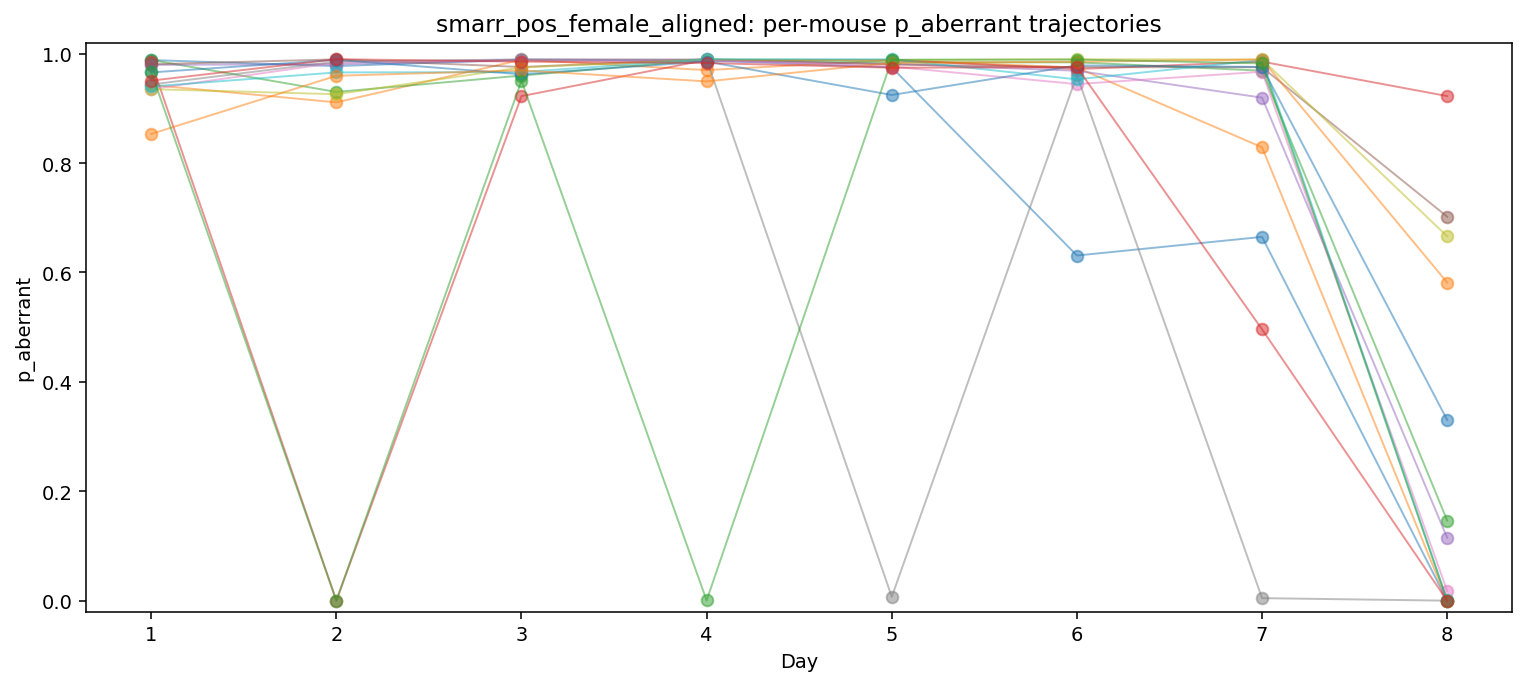

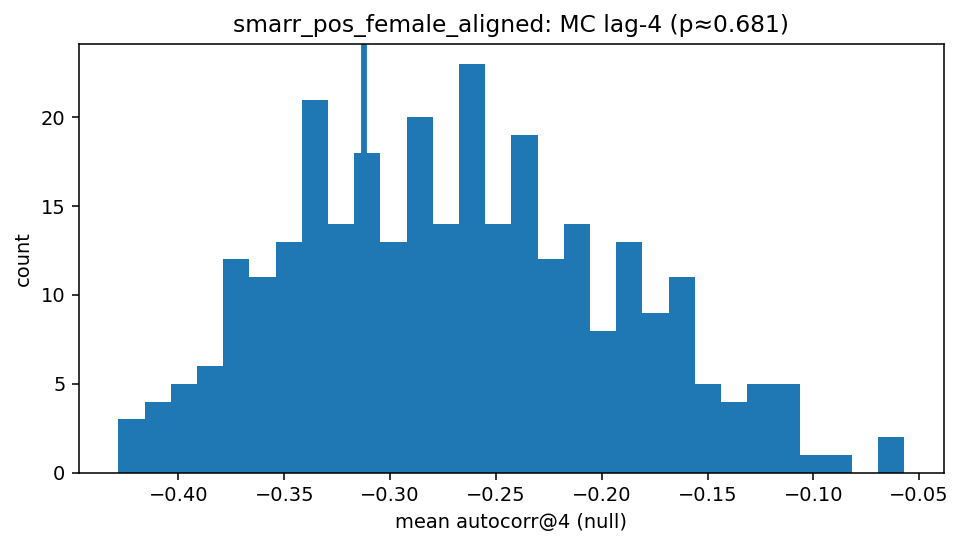

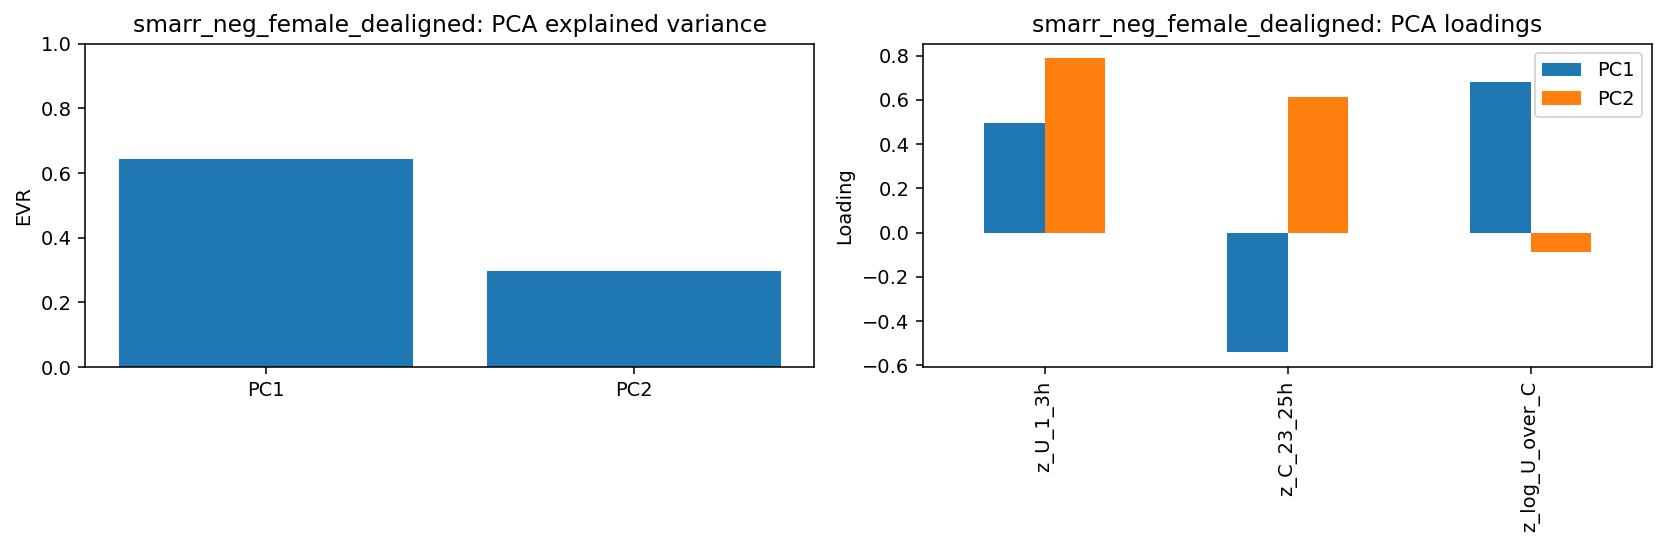

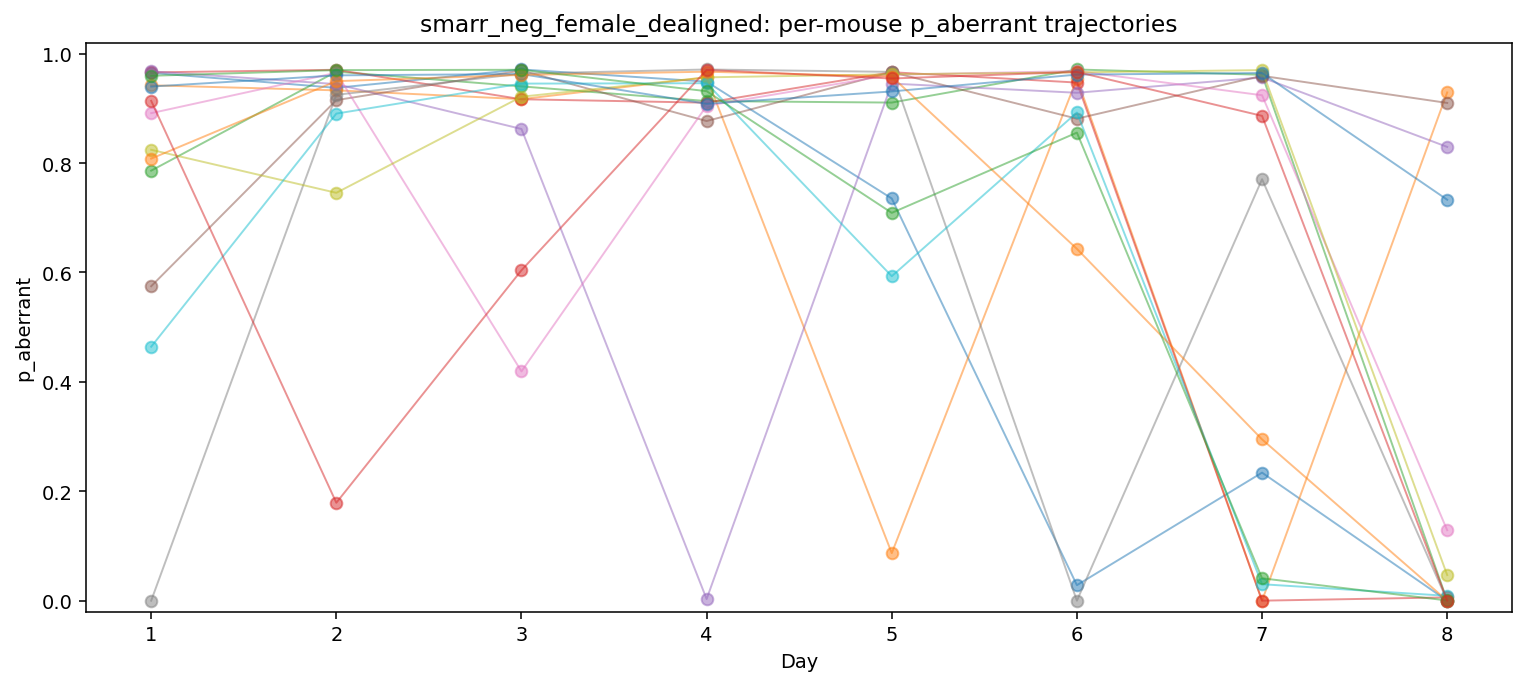

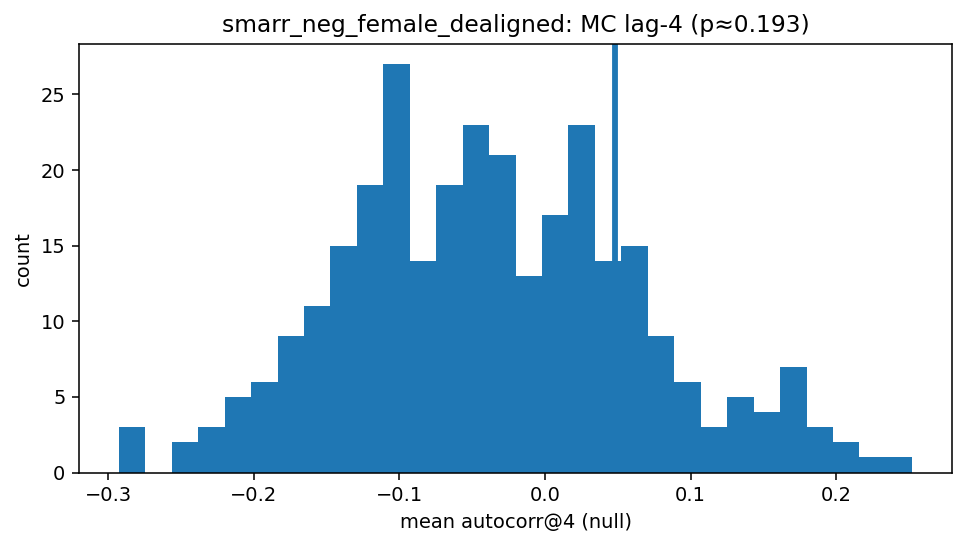

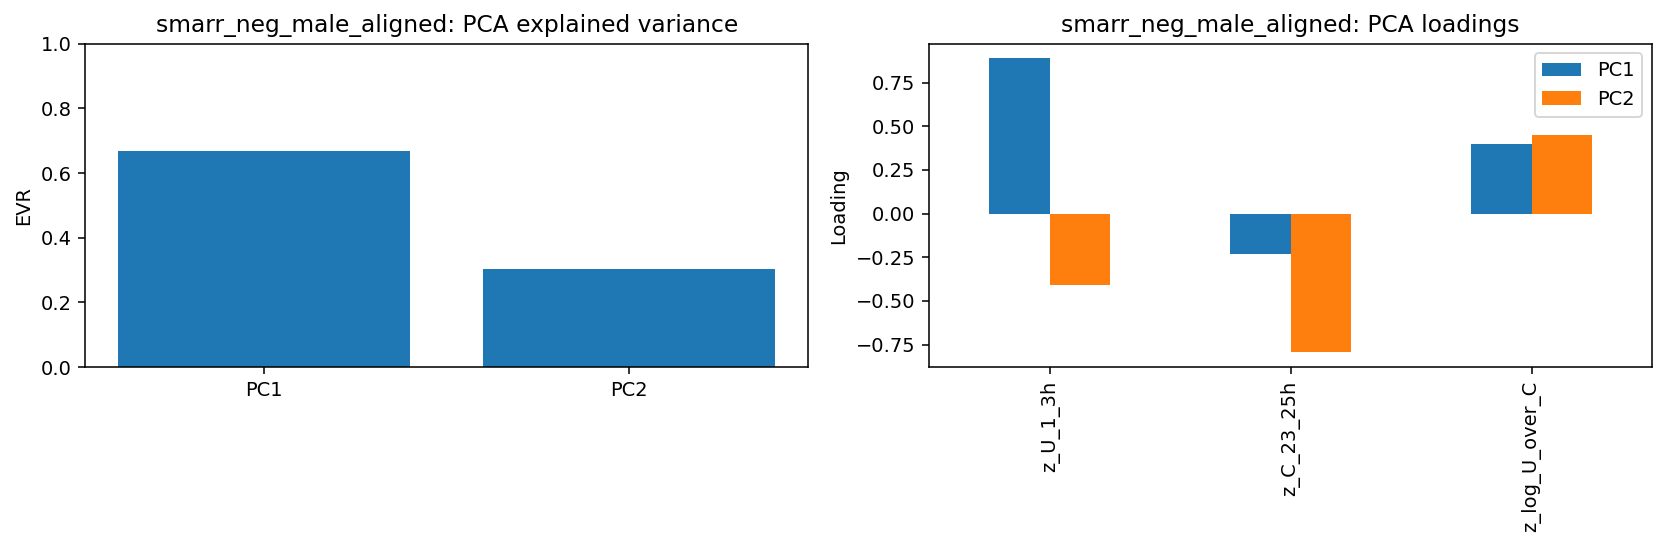

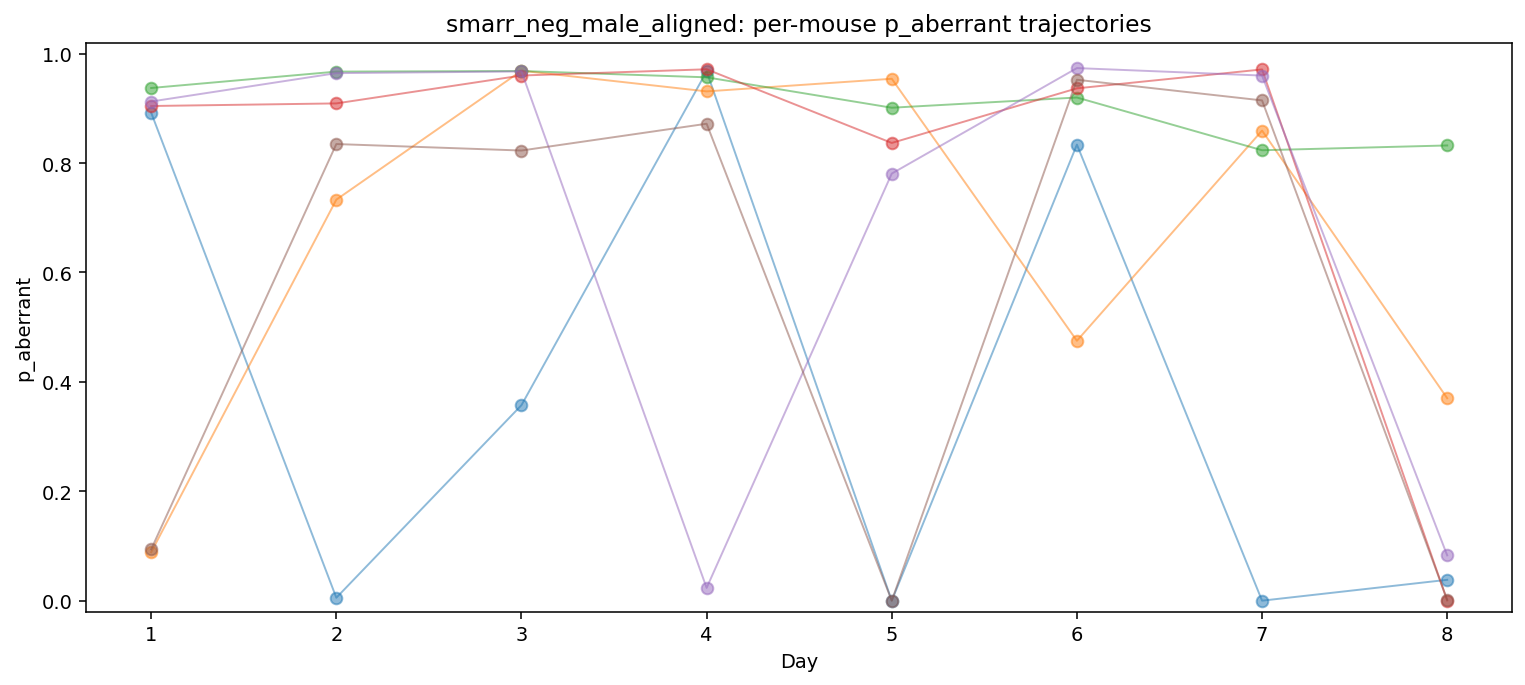

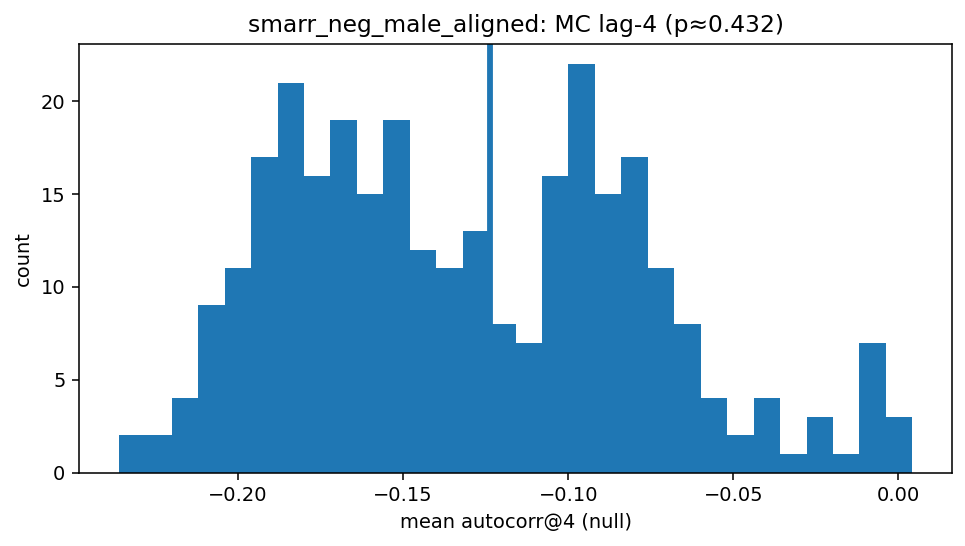

PIPELINE SUMMARY (Smarr controls: female positive + female dealigned negative + male negative)
                     group replicate  n_days_used  n_animals_qc  n_rows_qc  evr_pc1  evr_pc2  evr_cum  gmm_weights_comp0  gmm_weights_comp1  gmm_mean_zU_comp0  gmm_mean_zU_comp1  aberr_comp  obs_mean_autocorr_lag4_all_days  mc_pvalue_all_days
  smarr_pos_female_aligned     Smarr            8            14        112   0.6976   0.2277   0.9253             0.8294             0.1706             0.0454             1.2027           0                          -0.3123              0.6811
smarr_neg_female_dealigned     Smarr            8            14        112   0.6436   0.2985   0.9421             0.7301             0.2699             0.0158             1.0191           0                           0.0482              0.1927
    smarr_neg_male_aligned     Smarr            8             6         48   0.6691   0.3031   0.9722             0.6734             0.3266            -0.2246             1.318

In [5]:
# ============================================================
# SMARR POSITIVE + NEGATIVE CONTROL PIPELINE (ONE CELL)
# - Positive control: Smarr aligned females (12 days = 3 cycles; days 1,5,9 are estrus-like in Smarr)
# - Negative control A: Smarr maximally dealigned females (within-female day shifts)
# - Negative control B: Smarr MALE mice (negative control; same 12-day window)
# - Uses your NaN-preserving Monte Carlo null
# - Produces: summary_df, outliers_df + printed summary tables + CSVs
# ============================================================

# ----------------------------
# 0) Imports
# ----------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import cwt, morlet2
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

plt.rcParams["figure.dpi"] = 140
plt.rcParams["font.size"] = 10

# ----------------------------
# 1) Constants (match your pipeline)
# ----------------------------
MINUTES_PER_DAY = 1440
DAYS_SELECTED = 8                             # Smarr: 12 days selected
MINUTES_SELECTED = DAYS_SELECTED * MINUTES_PER_DAY

# (You can keep 1..39h for wavelets)
PERIODS_MINUTES = np.logspace(np.log10(60), np.log10(39 * 60), 50)  # 1h..39h
WAVELET_REDUCE = "max"
WAVELET_W = 5

# ----------------------------
# 2) Smarr loaders (female + male) - KEEP 12 DAYS (incl. day 9)
# ----------------------------
def _select_first_n_days(activity_2d, n_days=DAYS_SELECTED):
    """Trim to the first n_days * 1440 minutes (keeps day 9 because we keep all 12)."""
    n_animals, n_timepoints = activity_2d.shape
    need = n_days * MINUTES_PER_DAY
    if n_timepoints < need:
        raise ValueError(f"Not enough data: need {need} minutes ({n_days} days), have {n_timepoints}.")
    return activity_2d[:, :need]

def load_smarr_female_data(csv_path, n_days=DAYS_SELECTED):
    """
    Expects columns starting with 'fem' (case-insensitive).
    Returns: female_data (n_females, n_minutes_selected), n_females, n_days
    """
    df_smarr = pd.read_csv(csv_path)

    female_cols = [c for c in df_smarr.columns if str(c).lower().startswith("fem")]
    if len(female_cols) == 0:
        raise ValueError("No female columns found (expected columns starting with 'fem').")

    female_data = df_smarr[female_cols].to_numpy().T.astype(float)
    n_females, n_timepoints = female_data.shape
    print(f"Loaded Smarr FEMALE data: {n_females} females, {n_timepoints} minutes total")

    female_data = _select_first_n_days(female_data, n_days=n_days)
    print(f"Using first {n_days} days ({n_days*MINUTES_PER_DAY} minutes) per female (includes day 9)")

    return female_data, n_females, n_days

def load_smarr_male_data(csv_path, n_days=DAYS_SELECTED):
    """
    Expects columns starting with 'male' (case-insensitive).
    Returns: male_data (n_males, n_minutes_selected), n_males, n_days
    """
    df_smarr = pd.read_csv(csv_path)

    male_cols = [c for c in df_smarr.columns if str(c).lower().startswith("male")]
    if len(male_cols) == 0:
        raise ValueError(
            "No male columns found (expected columns starting with 'male'). "
            f"Columns seen: {list(df_smarr.columns)}"
        )

    male_data = df_smarr[male_cols].to_numpy().T.astype(float)
    n_males, n_timepoints = male_data.shape
    print(f"Loaded Smarr MALE data: {n_males} males, {n_timepoints} minutes total")

    male_data = _select_first_n_days(male_data, n_days=n_days)
    print(f"Using first {n_days} days ({n_days*MINUTES_PER_DAY} minutes) per male (includes day 9)")

    return male_data, n_males, n_days

def build_smarr_dealigned(activity_2d, minutes_per_day=MINUTES_PER_DAY):
    """
    Maximal dealignment by shifting each animal by i * 1 day (mod total length).
    This breaks the shared alignment to estrus day while preserving within-animal structure.
    """
    n_animals = activity_2d.shape[0]
    misaligned = np.empty_like(activity_2d)
    for i in range(n_animals):
        shift = (i * minutes_per_day) % activity_2d.shape[1]
        misaligned[i] = np.roll(activity_2d[i], -shift)
    return misaligned

# ----------------------------
# 3) Wavelet helpers
# ----------------------------
def compute_wavelet_power(signal_1min, periods_minutes=PERIODS_MINUTES, w=WAVELET_W):
    x = pd.Series(signal_1min).interpolate().bfill().ffill().fillna(0).values
    scales = periods_minutes * w / (2 * np.pi)
    coeffs = cwt(x, morlet2, scales, w=w)
    power = np.abs(coeffs) ** 2
    return power, periods_minutes

def extract_band_power_ts(power, periods_minutes, band_hours, reduce=WAVELET_REDUCE):
    periods_hours = periods_minutes / 60.0
    mask = (periods_hours >= band_hours[0]) & (periods_hours <= band_hours[1])
    if not np.any(mask):
        return np.zeros(power.shape[1], dtype=float)

    if reduce == "max":
        return np.max(power[mask, :], axis=0)
    elif reduce == "mean":
        return np.mean(power[mask, :], axis=0)
    else:
        raise ValueError("reduce must be 'max' or 'mean'")

def daily_mean_from_minute_ts(minute_ts, n_days):
    out = []
    for day in range(1, n_days + 1):
        s = (day - 1) * MINUTES_PER_DAY
        e = day * MINUTES_PER_DAY
        out.append(np.nanmean(minute_ts[s:e]) if e <= len(minute_ts) else np.nan)
    return np.array(out, dtype=float)

def robust_z(x, eps=1e-8):
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    return (x - med) / (mad + eps)

# ----------------------------
# 4) Cyclicity helpers (NaN-preserving MC null)
# ----------------------------
def autocorr_lag(series_by_day, lag=4):
    s = series_by_day.sort_index()
    s_shift = s.shift(-lag)

    mask = s.notna() & s_shift.notna()
    if mask.sum() < 3:
        return np.nan

    x0 = s[mask].values.astype(float)
    x1 = s_shift[mask].values.astype(float)

    if np.nanstd(x0) < 1e-10 or np.nanstd(x1) < 1e-10:
        return np.nan

    return float(np.corrcoef(x0, x1)[0, 1])

def circular_shift_preserve_nans(series_by_day, k):
    """
    Circularly shift only observed values while keeping NaN positions fixed.
    """
    s = series_by_day.sort_index()
    vals = s.to_numpy()
    n = len(vals)
    if n == 0:
        return s

    nanmask = ~np.isfinite(vals)
    obs = vals[~nanmask]
    m = len(obs)
    if m <= 1:
        return s

    k = int(k) % m
    if k == 0:
        return s

    obs_shifted = np.concatenate([obs[-k:], obs[:-k]])
    out = vals.copy()
    out[~nanmask] = obs_shifted
    return pd.Series(out, index=s.index)

def cyclicity_score(df, prob_col="p_aberrant", lag=4):
    acs = []
    for aid, g in df.groupby("animal_id"):
        s = g.set_index("day")[prob_col].sort_index()
        acs.append(autocorr_lag(s, lag=lag))
    acs = np.asarray(acs, dtype=float)
    return float(np.nanmean(acs)), acs

def monte_carlo_null(df, prob_col="p_aberrant", lag=4, n_sims=500, seed=0):
    rng = np.random.default_rng(seed)

    grids = {}
    obs_lengths = {}

    for aid, g in df.groupby("animal_id"):
        g = g.sort_values("day")
        dmin, dmax = int(g["day"].min()), int(g["day"].max())
        idx = pd.Index(range(dmin, dmax + 1), name="day")

        s = g.set_index("day")[prob_col].sort_index()
        s = s[~s.index.duplicated(keep="last")]
        s = s.reindex(idx)

        grids[aid] = s
        obs_lengths[aid] = int(np.sum(np.isfinite(s.to_numpy())))

    null = np.empty(n_sims, dtype=float)
    for i in range(n_sims):
        acs = []
        for aid, s in grids.items():
            m = obs_lengths[aid]
            k = int(rng.integers(0, m)) if m > 1 else 0
            s_shift = circular_shift_preserve_nans(s, k)
            acs.append(autocorr_lag(s_shift, lag=lag))
        null[i] = np.nanmean(acs)

    return null

# ----------------------------
# 5) Build feature table from Smarr matrix
# ----------------------------
def build_smarr_feature_table(activity_2d, label, n_days=DAYS_SELECTED, periods_minutes=PERIODS_MINUTES):
    """
    activity_2d: (n_animals, n_minutes_selected)
    Returns: one row per (animal_id, day) with wavelet features.
    """
    n_animals, n_minutes = activity_2d.shape
    expected = n_days * MINUTES_PER_DAY
    if n_minutes < expected:
        raise ValueError(f"{label}: expected >= {expected} minutes, got {n_minutes}")

    rows = []
    for aid in range(n_animals):
        x = activity_2d[aid].astype(float)

        power, periods = compute_wavelet_power(x, periods_minutes=periods_minutes, w=WAVELET_W)
        U_ts = extract_band_power_ts(power, periods, (1, 3), reduce=WAVELET_REDUCE)
        C_ts = extract_band_power_ts(power, periods, (23, 25), reduce=WAVELET_REDUCE)

        U_day = daily_mean_from_minute_ts(U_ts, n_days)
        C_day = daily_mean_from_minute_ts(C_ts, n_days)

        for day in range(1, n_days + 1):
            u = float(U_day[day - 1])
            c = float(C_day[day - 1])
            rows.append({
                "group": label,
                "replicate": "Smarr",
                "animal_id": int(aid),
                "day": int(day),
                "U_1_3h": u,
                "C_23_25h": c,
                "log_U_over_C": float(np.log((u + 1e-6) / (c + 1e-6))),
                # Smarr note: in females aligned to estrus, days 1, 5, 9 are estrus-like
                "is_estrus_like_day_1_5_9": int(day in (1, 5, 9)) if "female" in label.lower() and "aligned" in label.lower() else 0,
            })

    feat = pd.DataFrame(rows)
    if feat.empty:
        raise RuntimeError("Smarr feature table empty (unexpected).")
    return feat

# ----------------------------
# 6) Smarr analysis (PCA + GMM + MC lag-4)
# ----------------------------
def run_smarr_control(feat, n_sims=300, lag=4, show_plots=False):
    sub = feat.copy()

    # robust z per animal
    sub["z_U_1_3h"] = sub.groupby("animal_id")["U_1_3h"].transform(lambda s: robust_z(s.values))
    sub["z_C_23_25h"] = sub.groupby("animal_id")["C_23_25h"].transform(lambda s: robust_z(s.values))
    sub["z_log_U_over_C"] = sub.groupby("animal_id")["log_U_over_C"].transform(lambda s: robust_z(s.values))

    Z = ["z_U_1_3h", "z_C_23_25h", "z_log_U_over_C"]
    sub = sub.dropna(subset=Z).copy()

    # PCA
    pca = PCA(n_components=2, random_state=0)
    PC = pca.fit_transform(sub[Z].values)
    sub["PC1"], sub["PC2"] = PC[:, 0], PC[:, 1]

    evr = pca.explained_variance_ratio_
    loadings = pd.DataFrame(pca.components_.T, index=Z, columns=["PC1", "PC2"])

    # GMM on (z_U, z_log(U/C))
    Xg = sub[["z_U_1_3h", "z_log_U_over_C"]].values
    gmm = GaussianMixture(n_components=2, covariance_type="full", reg_covar=1e-6, random_state=0)
    gmm.fit(Xg)

    post = gmm.predict_proba(Xg)
    hard = gmm.predict(Xg)

    mean_zU_by_comp = [sub.loc[hard == k, "z_U_1_3h"].mean() for k in [0, 1]]
    aberr_comp = int(np.argmin(mean_zU_by_comp))
    sub["p_aberrant"] = post[:, aberr_comp]

    # cyclicity (all days)
    obs_ac, _ = cyclicity_score(sub, prob_col="p_aberrant", lag=lag)
    null = monte_carlo_null(sub, prob_col="p_aberrant", lag=lag, n_sims=n_sims, seed=0)
    null_f = null[np.isfinite(null)]
    p_mc = float((np.sum(null_f >= obs_ac) + 1) / (len(null_f) + 1)) if len(null_f) else np.nan

    # outliers (PCA radius)
    sub["pc_r2"] = sub["PC1"] ** 2 + sub["PC2"] ** 2
    outliers = sub.sort_values("pc_r2", ascending=False).head(10)[
        ["group","replicate","animal_id","day","PC1","PC2",
         "U_1_3h","C_23_25h","log_U_over_C",
         "z_U_1_3h","z_C_23_25h","z_log_U_over_C",
         "p_aberrant","pc_r2"]
    ].copy()

    if show_plots:
        # PCA EVR + loadings
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].bar(["PC1", "PC2"], [evr[0], evr[1]])
        axes[0].set_ylim(0, 1)
        axes[0].set_title(f"{sub['group'].iloc[0]}: PCA explained variance")
        axes[0].set_ylabel("EVR")

        loadings.plot(kind="bar", ax=axes[1])
        axes[1].set_title(f"{sub['group'].iloc[0]}: PCA loadings")
        axes[1].set_ylabel("Loading")
        plt.tight_layout()
        plt.show()

        # p_aberrant trajectories
        plt.figure(figsize=(11, 5))
        for aid, g in sub.sort_values(["animal_id","day"]).groupby("animal_id"):
            plt.plot(g["day"], g["p_aberrant"], marker="o", alpha=0.5, linewidth=1)
        plt.ylim(-0.02, 1.02)
        plt.xlabel("Day")
        plt.ylabel("p_aberrant")
        plt.title(f"{sub['group'].iloc[0]}: per-mouse p_aberrant trajectories")
        plt.tight_layout()
        plt.show()

        # MC null histogram
        plt.figure(figsize=(7, 4))
        plt.hist(null_f, bins=30)
        if np.isfinite(obs_ac):
            plt.axvline(obs_ac, linewidth=3)
        plt.xlabel(f"mean autocorr@{lag} (null)")
        plt.ylabel("count")
        plt.title(f"{sub['group'].iloc[0]}: MC lag-{lag} (p≈{p_mc:.3g})")
        plt.tight_layout()
        plt.show()

    summary = {
        "group": str(sub["group"].iloc[0]),
        "replicate": "Smarr",
        "n_days_used": int(sub["day"].nunique()),

        "n_animals_qc": int(sub["animal_id"].nunique()),
        "n_rows_qc": int(len(sub)),

        "evr_pc1": float(evr[0]),
        "evr_pc2": float(evr[1]),
        "evr_cum": float(np.sum(evr)),

        "gmm_weights_comp0": float(gmm.weights_[0]),
        "gmm_weights_comp1": float(gmm.weights_[1]),
        "gmm_mean_zU_comp0": float(mean_zU_by_comp[0]),
        "gmm_mean_zU_comp1": float(mean_zU_by_comp[1]),
        "aberr_comp": int(aberr_comp),

        "obs_mean_autocorr_lag4_all_days": float(obs_ac),
        "mc_pvalue_all_days": float(p_mc),

        "loadings": loadings.round(4).to_string(),
    }

    return sub, summary, outliers

# ----------------------------
# 7) RUN: female aligned + female dealigned + male negative control
# ----------------------------
CSV_FEMALE = "mice data.xlsx - FemAct (1).csv"
CSV_MALE   = "mice data.xlsx - MaleAct.csv"   # update if needed

# Females (positive + dealigned negative)
aligned_f, n_females, n_days = load_smarr_female_data(CSV_FEMALE, n_days=DAYS_SELECTED)
dealigned_f = build_smarr_dealigned(aligned_f)

feat_pos = build_smarr_feature_table(aligned_f,   label="smarr_pos_female_aligned", n_days=DAYS_SELECTED)
feat_neg = build_smarr_feature_table(dealigned_f, label="smarr_neg_female_dealigned", n_days=DAYS_SELECTED)

# Males (negative control)
aligned_m, n_males, _ = load_smarr_male_data(CSV_MALE, n_days=DAYS_SELECTED)
feat_male = build_smarr_feature_table(aligned_m, label="smarr_neg_male_aligned", n_days=DAYS_SELECTED)

# Toggle plots here:
SHOW_PLOTS = True
N_SIMS = 300
LAG = 4

sub_pos, summary_pos, outliers_pos = run_smarr_control(feat_pos,  n_sims=N_SIMS, lag=LAG, show_plots=SHOW_PLOTS)
sub_neg, summary_neg, outliers_neg = run_smarr_control(feat_neg,  n_sims=N_SIMS, lag=LAG, show_plots=SHOW_PLOTS)
sub_mal, summary_mal, outliers_mal = run_smarr_control(feat_male, n_sims=N_SIMS, lag=LAG, show_plots=SHOW_PLOTS)

summary_df = pd.DataFrame([summary_pos, summary_neg, summary_mal])
outliers_df = pd.concat([outliers_pos, outliers_neg, outliers_mal], ignore_index=True)

# ----------------------------
# 8) OUTPUT SUMMARY TABLES
# ----------------------------
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 200)

print("=" * 120)
print("PIPELINE SUMMARY (Smarr controls: female positive + female dealigned negative + male negative)")
print("=" * 120)

cols = [
    "group", "replicate", "n_days_used",
    "n_animals_qc", "n_rows_qc",
    "evr_pc1", "evr_pc2", "evr_cum",
    "gmm_weights_comp0", "gmm_weights_comp1",
    "gmm_mean_zU_comp0", "gmm_mean_zU_comp1",
    "aberr_comp",
    "obs_mean_autocorr_lag4_all_days", "mc_pvalue_all_days",
]
print(summary_df[cols].round(4).to_string(index=False))

print("\n" + "=" * 120)
print("PCA LOADINGS (Smarr controls)")
print("=" * 120)
for _, row in summary_df.iterrows():
    print("\n" + "-" * 120)
    print(
        f"{row['group']} {row['replicate']} | "
        f"EVR: [{row['evr_pc1']:.4f}, {row['evr_pc2']:.4f}] (cum={row['evr_cum']:.4f})"
    )
    print(row["loadings"])

print("\n" + "=" * 120)
print("TOP PCA OUTLIERS (Smarr controls)")
print("=" * 120)
print(outliers_df.to_string(index=False))

# ----------------------------
# 9) SAVE CSVs (optional)
# ----------------------------
summary_df.to_csv("smarr_controls_pipeline_summary.csv", index=False)
outliers_df.to_csv("smarr_controls_pipeline_outliers.csv", index=False)

print("\nSaved CSVs:")
print("- smarr_controls_pipeline_summary.csv")
print("- smarr_controls_pipeline_outliers.csv")

# Objects you now have in memory:
# - summary_df
# - outliers_df
# - sub_pos, sub_neg, sub_mal (day-level tables with p_aberrant, PCs, z-features)